# 05-03 · Sensitivity Analysis

Tests whether the Historical vs. Future climate change signal is robust to:

1. **Rain filter threshold** — how sensitive are the CDF curves to the minimum
   rainfall cutoff (0 / 5 / 10 / 15 / 20 mm)?
2. **Spatial shift range** — does restricting to near-centre storms
   (±5 / ±10 / ±15 / ±20 km) change the conclusion?

Both sweeps show the **Pareto uncertainty band** (ensemble envelope across all
available members), so the sensitivity of the parameter uncertainty — not just
the optimum — is evaluated.


In [5]:
from pathlib import Path
import numpy as np

RAW_DIR = Path(r"D:\MY_CODES\UrbanRunoffModeling_Refactored\outputs\climate\raw")
FIG_DIR = Path(r"D:\MY_CODES\UrbanRunoffModeling_Refactored\outputs\climate\figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

PARETO_INDICES  = [682, 701, 708, 709, 710, 717, 718, 719, 727, 728, 898, 917]
OPTIMUM_IDX     = 708
DEFAULT_RAIN_MM = 10.0
DEFAULT_SHIFT_M = 20_000

# Change this to 2.0 (or any other multiplier) to analyse a different scenario.
URBAN_SCENARIO = 2.0

# Sensitivity sweep values
RAIN_THRESHOLDS_MM  = [0, 5, 10, 15, 20]
SHIFT_THRESHOLDS_M  = [5_000, 10_000, 15_000, 20_000]

# Column references (4-level MultiIndex: urban_mult, condition, category, metric)
_C_EV = ("event_num",    "",              "",                ""               )
_C_Y  = ("y",            "",              "",                ""               )
_C_RH = (URBAN_SCENARIO, "historical",   "full_basin",      "total_rain"     )
_C_RF = (URBAN_SCENARIO, "future",       "full_basin",      "total_rain"     )
_C_PH = (URBAN_SCENARIO, "historical",   "basin discharge", "max_discharge"  )
_C_PF = (URBAN_SCENARIO, "future",       "basin discharge", "max_discharge"  )
_C_VH = (URBAN_SCENARIO, "historical",   "basin discharge", "total_discharge")
_C_VF = (URBAN_SCENARIO, "future",       "basin discharge", "total_discharge")


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.patches import Patch

plt.rcParams.update({"font.family": "Arial", "font.size": 13, "axes.linewidth": 1.0})

_HIST_COLOR = "#1E3A5F"
_HIST_FILL  = "#89AED2"
_FUT_COLOR  = "#7B1121"
_FUT_FILL   = "#E594A4"
_PCT_TICKS  = np.array([0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99])


def _logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log10(p / (1 - p))

def _make_x_grid(arrays, n=512):
    lo = min(float(a.min()) for a in arrays if len(a) > 0)
    hi = max(float(a.max()) for a in arrays if len(a) > 0)
    if lo >= hi:
        lo, hi = lo - 1e-9, hi + 1e-9
    return np.linspace(lo, hi, n)

def _ecdf_on_grid(values, x_grid):
    v = np.sort(np.asarray(values, dtype=float))
    return np.searchsorted(v, x_grid, side="right") / float(v.size)

def _filter_events(df, rain_mm, shift_m):
    bad = []
    for ev in df[_C_EV].unique():
        sub = df[df[_C_EV] == ev]
        if (sub[_C_RH] < rain_mm).all() and (sub[_C_RF] < rain_mm).all():
            bad.append(ev)
    df = df[~df[_C_EV].isin(bad)]
    valid_y = np.arange(-shift_m, shift_m + 1, 500).astype(int)
    return df[df[_C_Y].isin(valid_y)], len(bad)


available = [i for i in PARETO_INDICES
             if (RAW_DIR / f"pareto_{i}_results.pkl").exists()]
if not available:
    raise RuntimeError("No pickles found. Run 05_01_SWMM_Ensemble_Runner.ipynb first.")

# Cache all raw DataFrames to avoid re-reading for every threshold value
print(f"Loading {len(available)} member pickles into memory ...")
raw_dfs = {i: pd.read_pickle(str(RAW_DIR / f"pareto_{i}_results.pkl"))
           for i in available}
print("Done.")

opt_idx = OPTIMUM_IDX if OPTIMUM_IDX in available else available[0]


def _build_envelope_for_params(raw_dfs, col_h, col_f, rain_mm, shift_m):
    """Apply filter + build Pareto envelope ECDFs for given threshold params."""
    all_h, all_f = [], []
    for df_raw in raw_dfs.values():
        df, _ = _filter_events(df_raw, rain_mm, shift_m)
        all_h.append(df[col_h].values.astype(float))
        all_f.append(df[col_f].values.astype(float))

    x_grid = _make_x_grid(all_h + all_f)
    ecdfs_h = np.stack([_ecdf_on_grid(v, x_grid) for v in all_h])
    ecdfs_f = np.stack([_ecdf_on_grid(v, x_grid) for v in all_f])

    opt_df, _ = _filter_events(raw_dfs[opt_idx], rain_mm, shift_m)
    F_h_opt = _ecdf_on_grid(opt_df[col_h].values.astype(float), x_grid)
    F_f_opt = _ecdf_on_grid(opt_df[col_f].values.astype(float), x_grid)

    n_sims = sum(len(v) for v in all_h) * 2
    n_ev   = opt_df[_C_EV].nunique()
    return (x_grid,
            ecdfs_h.min(0), ecdfs_h.max(0), F_h_opt,
            ecdfs_f.min(0), ecdfs_f.max(0), F_f_opt,
            n_sims, n_ev)


def _draw_sensitivity_panel(ax, x, F_h_opt, F_f_opt,
                             env_h_lo, env_h_hi, env_f_lo, env_f_hi,
                             x_label, title, n_sims, n_ev, panel_label=None):
    L = _logit
    ax.fill_between(x, L(env_h_lo), L(env_h_hi), color=_HIST_FILL, alpha=0.40, linewidth=0)
    ax.fill_between(x, L(env_f_lo), L(env_f_hi), color=_FUT_FILL,  alpha=0.40, linewidth=0)
    ax.plot(x, L(F_h_opt), lw=1.6, color=_HIST_COLOR)
    ax.plot(x, L(F_f_opt), lw=1.6, color=_FUT_COLOR)

    ax.set_yticks(L(_PCT_TICKS))
    ax.set_yticklabels([f"{int(p*100)}%" for p in _PCT_TICKS], fontsize=11)
    ax.set_ylim(-3, 3)
    ax.set_ylabel("CDF", fontsize=13)
    ax.set_xlabel(x_label, fontsize=13)
    ax.set_xlim(left=x.min())
    ax.set_title(title, fontsize=14)
    ax.grid(True, ls="--", lw=0.5, alpha=0.5, zorder=0)
    for sp in ax.spines.values():
        sp.set_color("black"); sp.set_linewidth(1.0)
    ax.tick_params(axis="both", direction="in", length=4, width=0.8,
                   colors="black", labelsize=11)
    ax.minorticks_on()
    ax.text(0.97, 0.05, f"{n_ev} events | n={n_sims:,}",
            transform=ax.transAxes, fontsize=10, ha="right", va="bottom",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="none"))
    if panel_label:
        ax.text(-0.07, 1.04, panel_label, transform=ax.transAxes,
                fontsize=15, fontweight="bold", ha="left", va="bottom")

print("Utility functions defined.")


RuntimeError: No pickles found. Run 05_01_SWMM_Ensemble_Runner.ipynb first.

Computing rain-threshold sensitivity (peak discharge) ...
Saved: D:\MY_CODES\UrbanRunoffModeling_Refactored\outputs\climate\figures\Fig_Sensitivity_RainThreshold_Peak.pdf


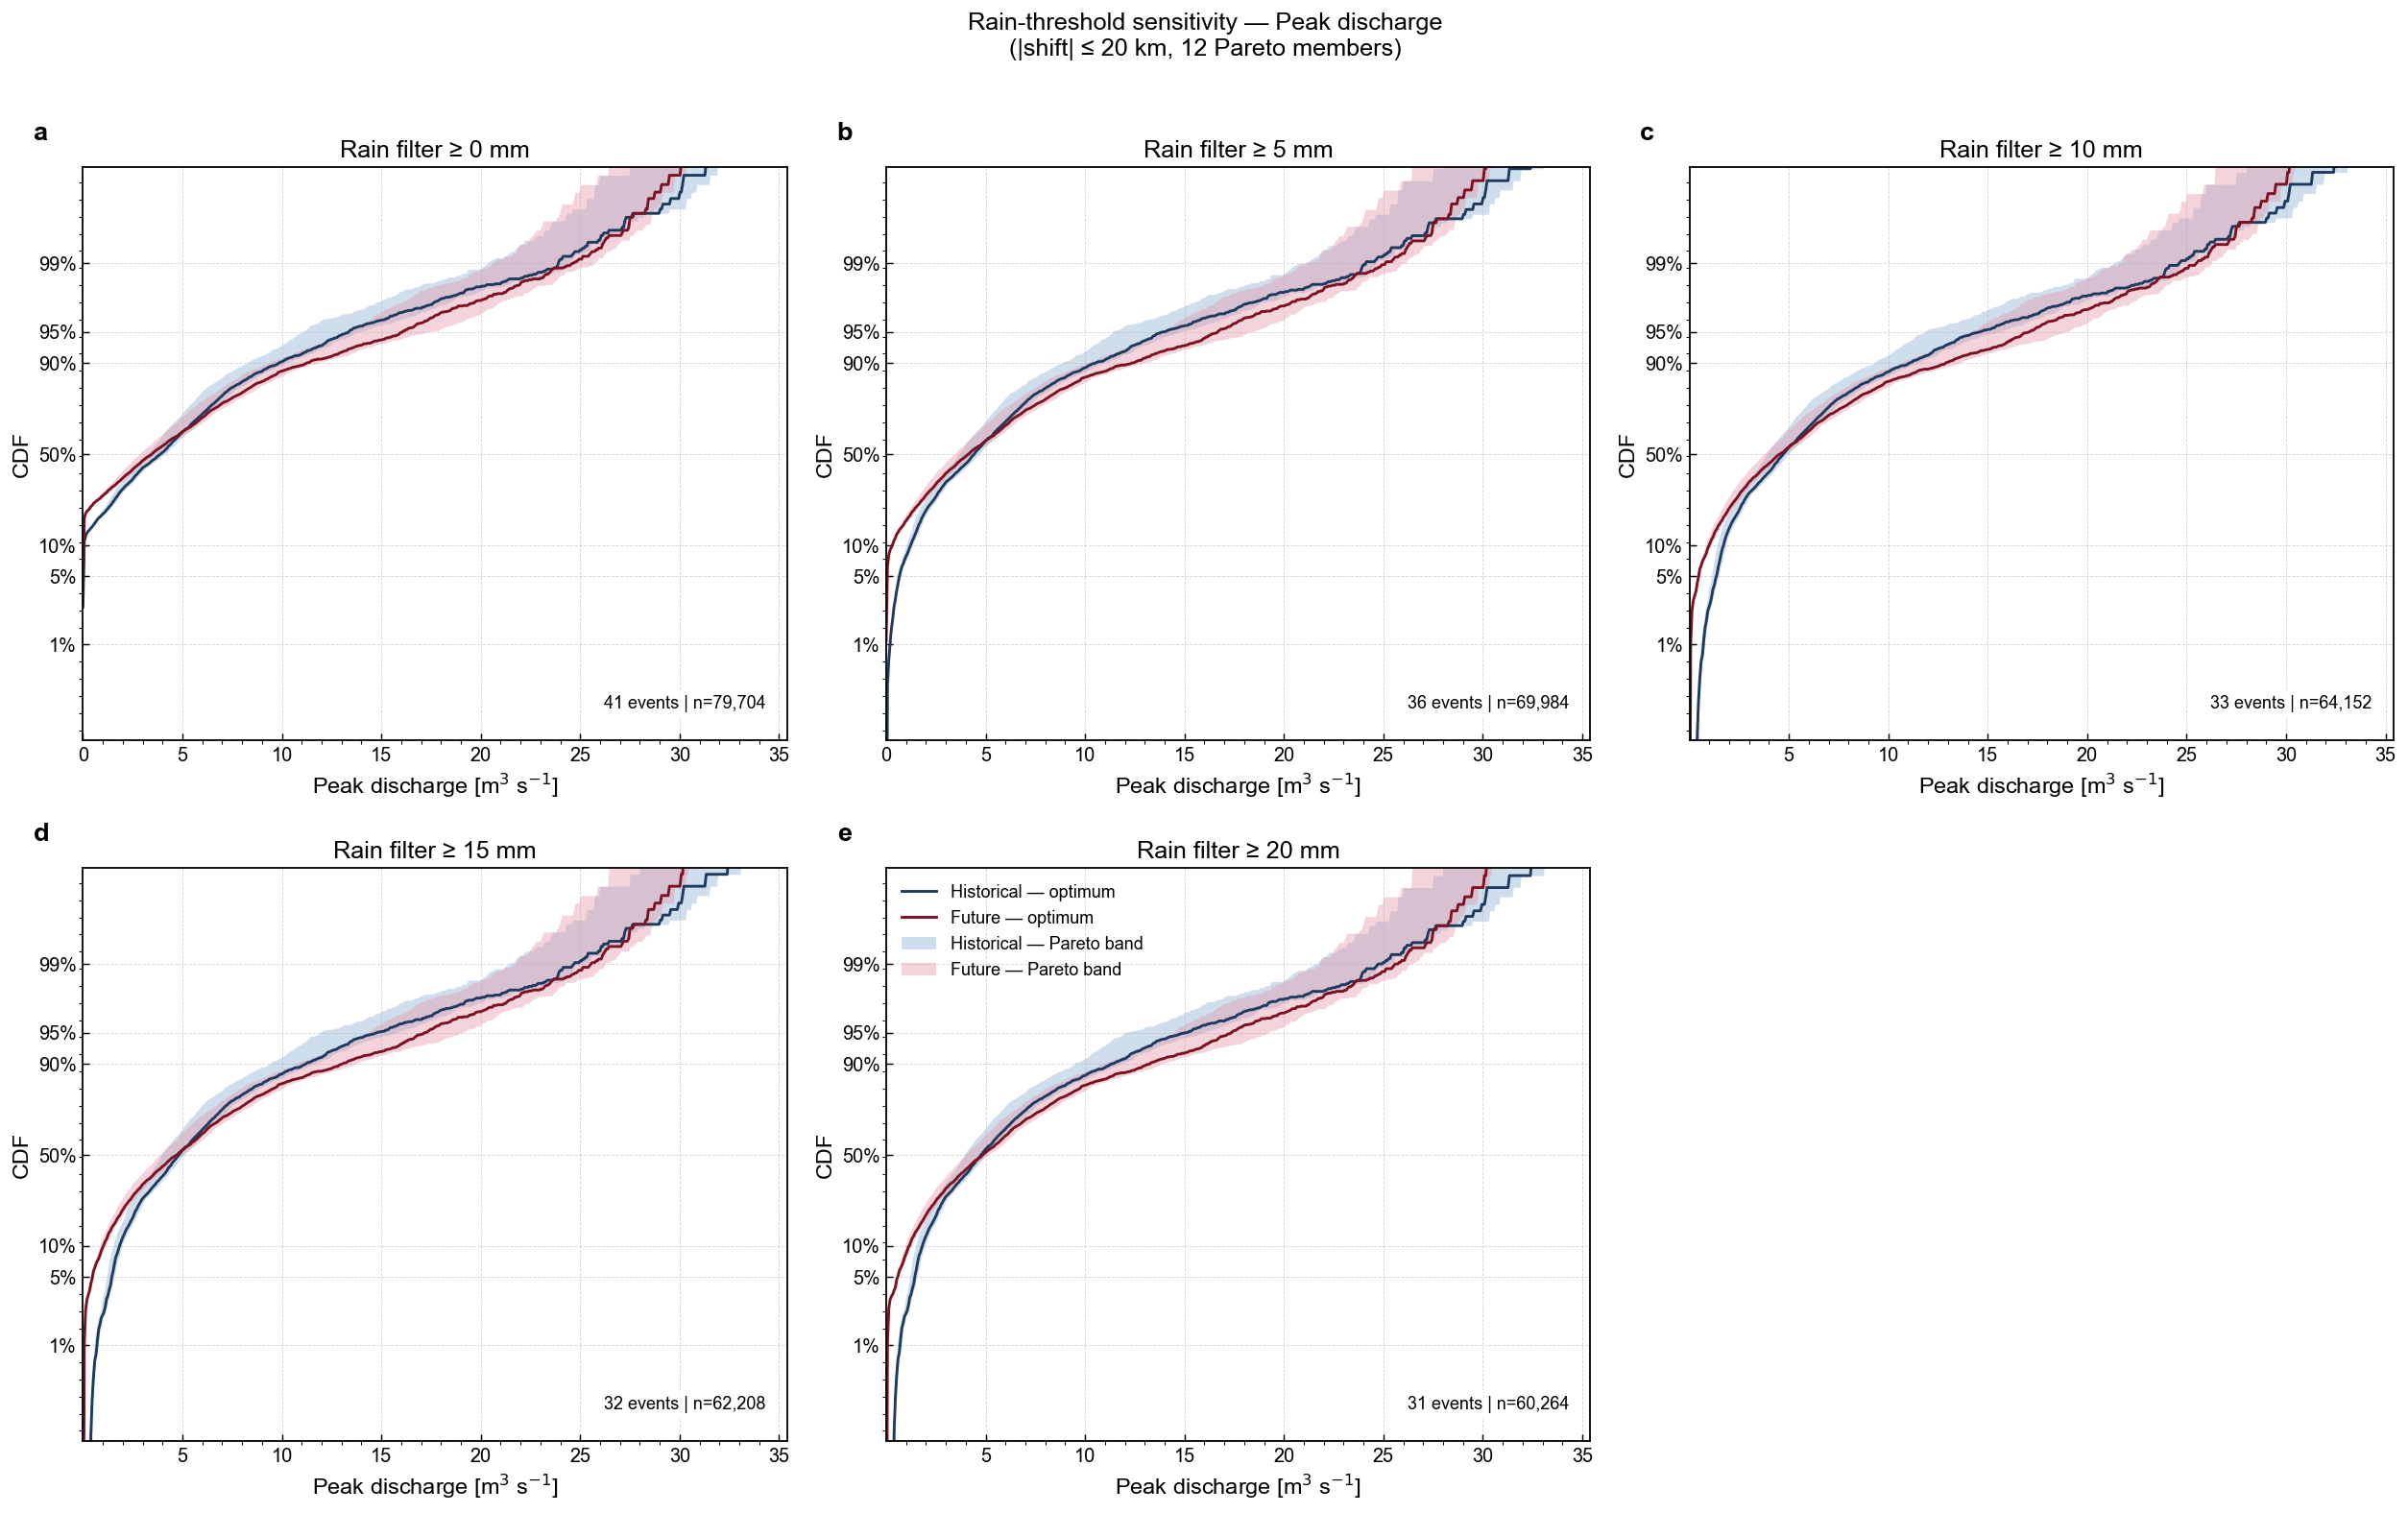

In [ ]:
# ── Section 1: Rain-threshold sensitivity ─────────────────────────────────────
# Each panel: Pareto ensemble CDF for peak discharge at one rain threshold.
print("Computing rain-threshold sensitivity (peak discharge) ...")

ncols = 3
nrows = -(-len(RAIN_THRESHOLDS_MM) // ncols)
x_label = r"Peak discharge [m$^3$ s$^{-1}$]"
panel_labels = "abcde"

fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 6.0 * nrows), dpi=130)
axes_flat  = np.atleast_1d(axes).ravel()

for i, thr in enumerate(RAIN_THRESHOLDS_MM):
    (x, eh_lo, eh_hi, F_h_opt,
     ef_lo, ef_hi, F_f_opt,
     n_sims, n_ev) = _build_envelope_for_params(
         raw_dfs, _C_PH, _C_PF, rain_mm=thr, shift_m=DEFAULT_SHIFT_M
     )
    _draw_sensitivity_panel(
        axes_flat[i], x, F_h_opt, F_f_opt,
        eh_lo, eh_hi, ef_lo, ef_hi,
        x_label=x_label,
        title=f"Rain filter \u2265 {thr} mm",
        n_sims=n_sims, n_ev=n_ev,
        panel_label=panel_labels[i],
    )

for j in range(len(RAIN_THRESHOLDS_MM), len(axes_flat)):
    axes_flat[j].set_visible(False)

# Shared legend in last visible axis
handles = [
    mlines.Line2D([], [], color=_HIST_COLOR, lw=1.6, label="Historical — optimum"),
    mlines.Line2D([], [], color=_FUT_COLOR,  lw=1.6, label="Future — optimum"),
    Patch(facecolor=_HIST_FILL, alpha=0.4, edgecolor="none", label="Historical — Pareto band"),
    Patch(facecolor=_FUT_FILL,  alpha=0.4, edgecolor="none", label="Future — Pareto band"),
]
axes_flat[len(RAIN_THRESHOLDS_MM) - 1].legend(
    handles=handles, frameon=False, fontsize=10, loc="upper left"
)

fig.suptitle(
    f"Rain-threshold sensitivity — Peak discharge\n"
    f"(|shift| \u2264 {DEFAULT_SHIFT_M // 1000} km, {len(available)} Pareto members)",
    fontsize=14, y=1.01,
)
fig.tight_layout()
out = FIG_DIR / "Fig_Sensitivity_RainThreshold_Peak.pdf"
fig.savefig(str(out), format="pdf", bbox_inches="tight", dpi=300)
print(f"Saved: {out}")
plt.show()


Computing rain-threshold sensitivity (total volume) ...
Saved: D:\MY_CODES\UrbanRunoffModeling_Refactored\outputs\climate\figures\Fig_Sensitivity_RainThreshold_Volume.pdf


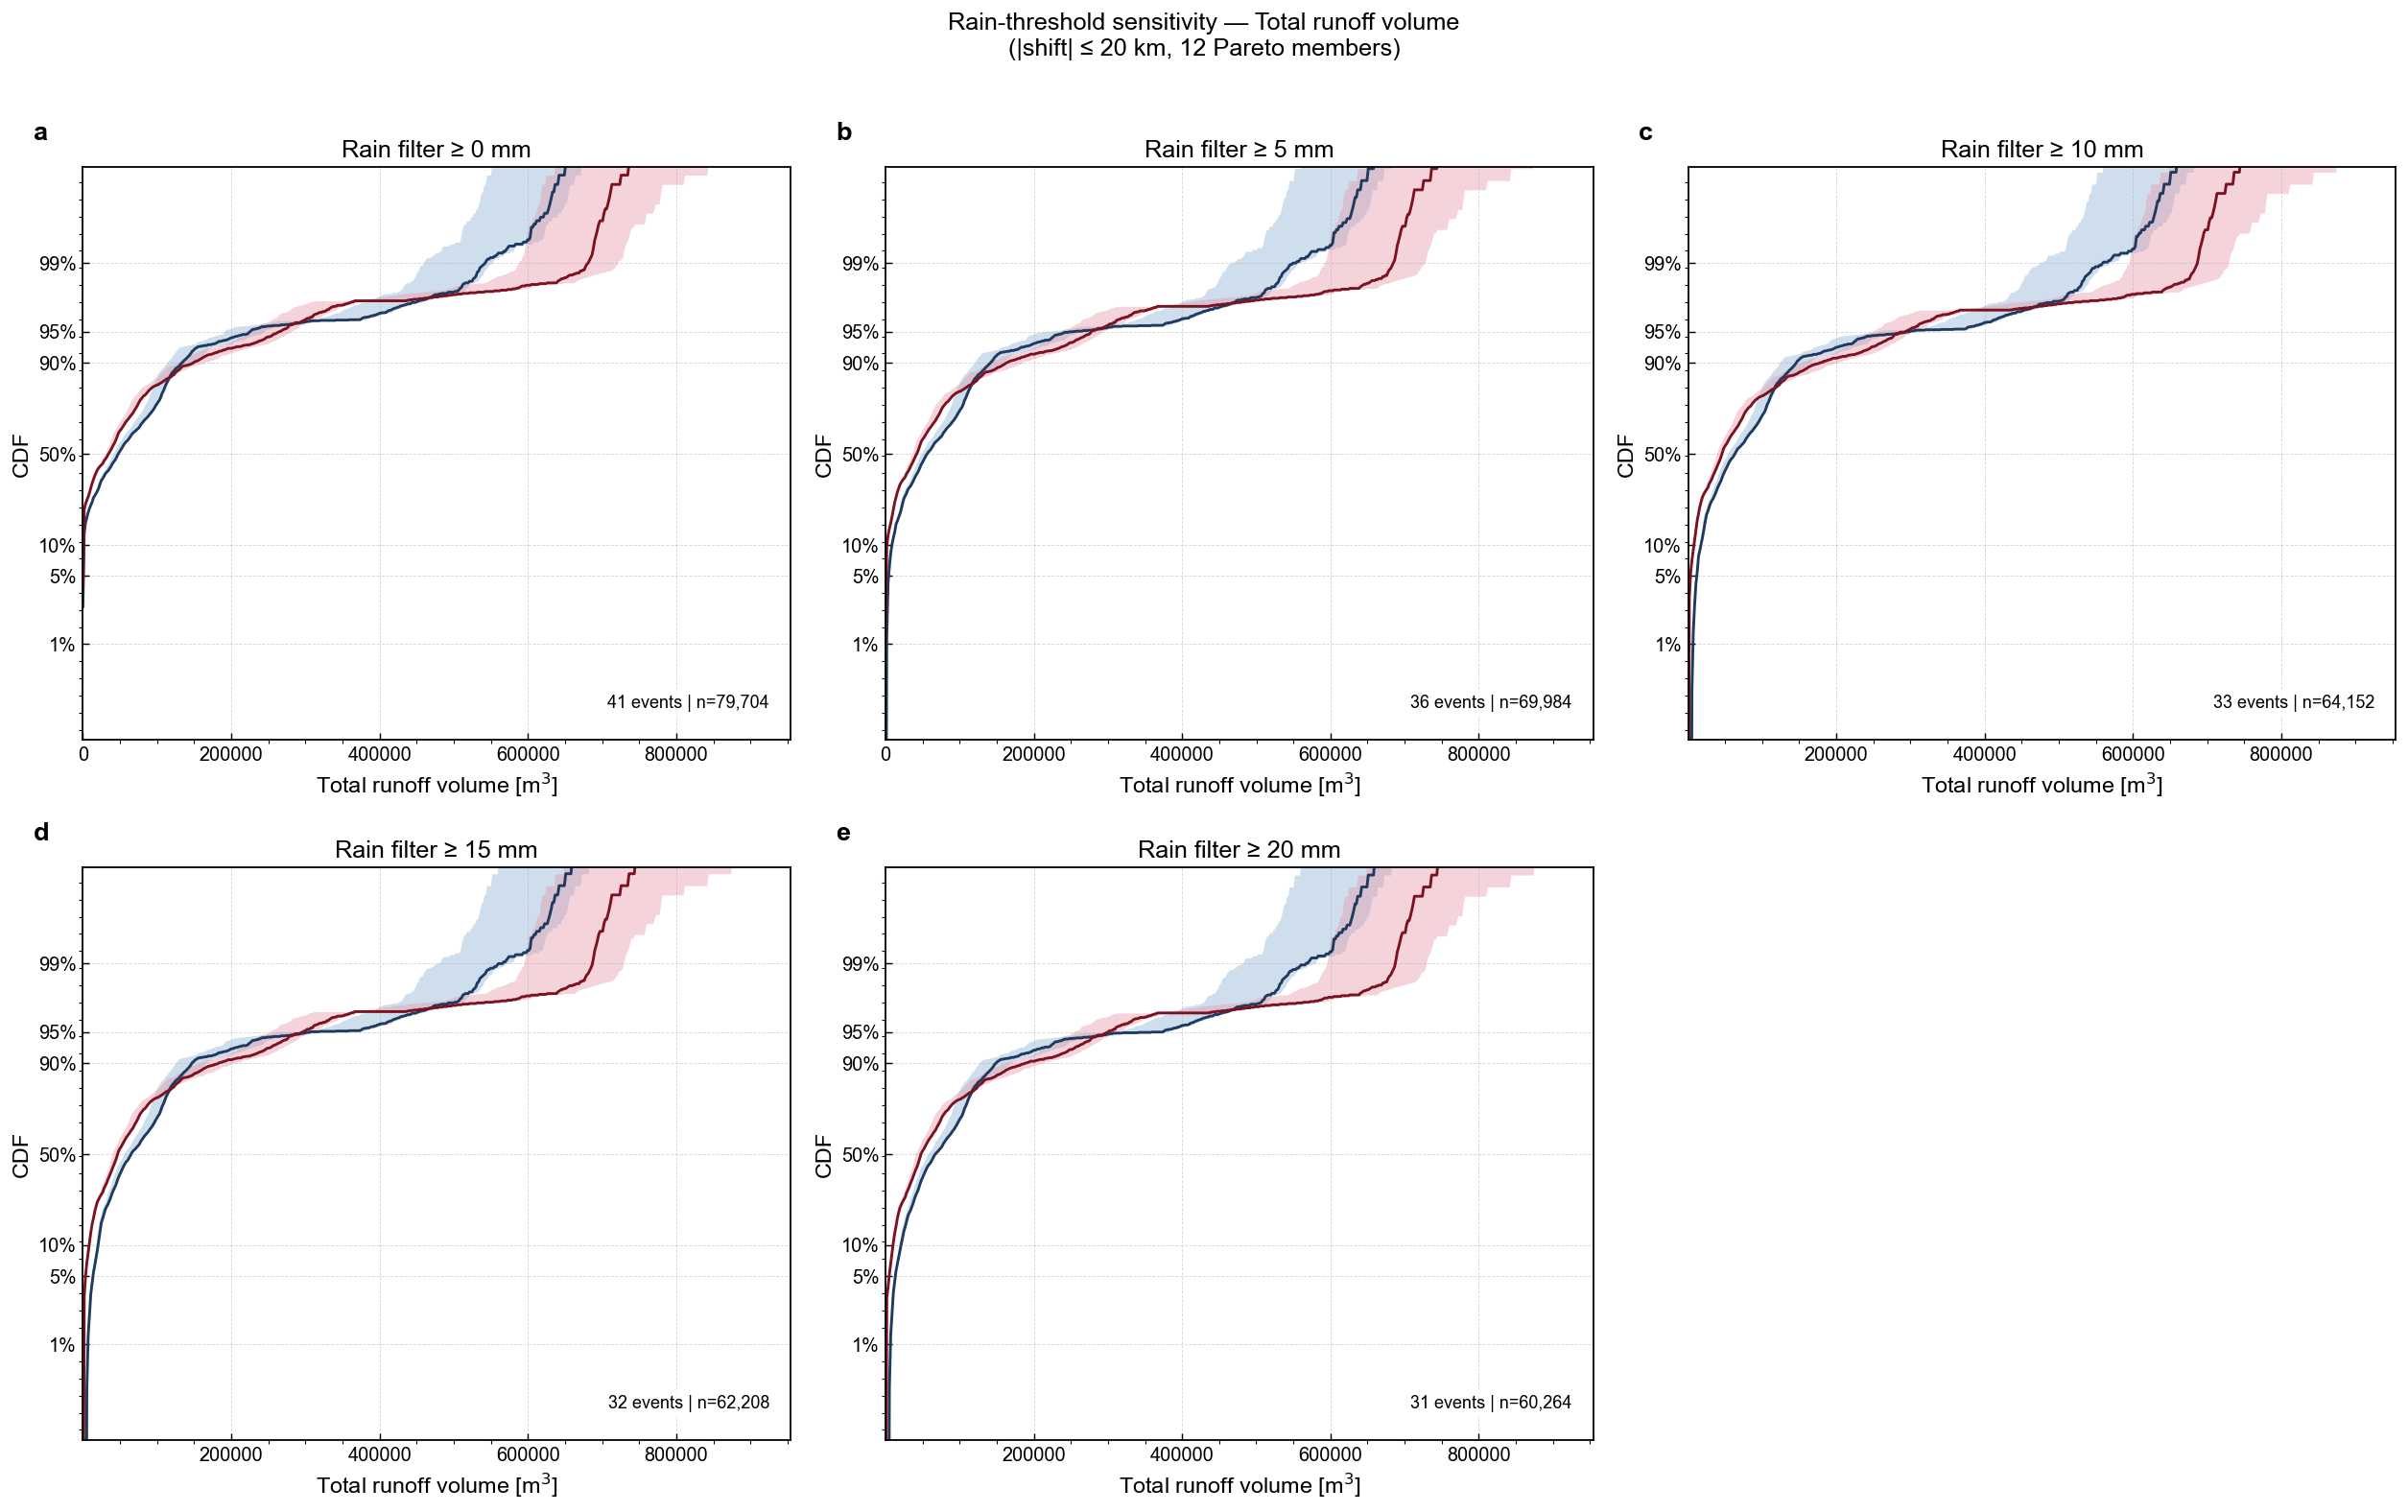

In [ ]:
# ── Section 2: Rain-threshold sensitivity — total volume ──────────────────────
print("Computing rain-threshold sensitivity (total volume) ...")
x_label_vol = r"Total runoff volume [m$^3$]"

fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 6.0 * nrows), dpi=130)
axes_flat  = np.atleast_1d(axes).ravel()

for i, thr in enumerate(RAIN_THRESHOLDS_MM):
    (x, eh_lo, eh_hi, F_h_opt,
     ef_lo, ef_hi, F_f_opt,
     n_sims, n_ev) = _build_envelope_for_params(
         raw_dfs, _C_VH, _C_VF, rain_mm=thr, shift_m=DEFAULT_SHIFT_M
     )
    _draw_sensitivity_panel(
        axes_flat[i], x, F_h_opt, F_f_opt,
        eh_lo, eh_hi, ef_lo, ef_hi,
        x_label=x_label_vol,
        title=f"Rain filter \u2265 {thr} mm",
        n_sims=n_sims, n_ev=n_ev,
        panel_label=panel_labels[i],
    )

for j in range(len(RAIN_THRESHOLDS_MM), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(
    f"Rain-threshold sensitivity — Total runoff volume\n"
    f"(|shift| \u2264 {DEFAULT_SHIFT_M // 1000} km, {len(available)} Pareto members)",
    fontsize=14, y=1.01,
)
fig.tight_layout()
out = FIG_DIR / "Fig_Sensitivity_RainThreshold_Volume.pdf"
fig.savefig(str(out), format="pdf", bbox_inches="tight", dpi=300)
print(f"Saved: {out}")
plt.show()


Computing shift-threshold sensitivity (peak discharge) ...
Saved: D:\MY_CODES\UrbanRunoffModeling_Refactored\outputs\climate\figures\Fig_Sensitivity_ShiftThreshold_Peak.pdf


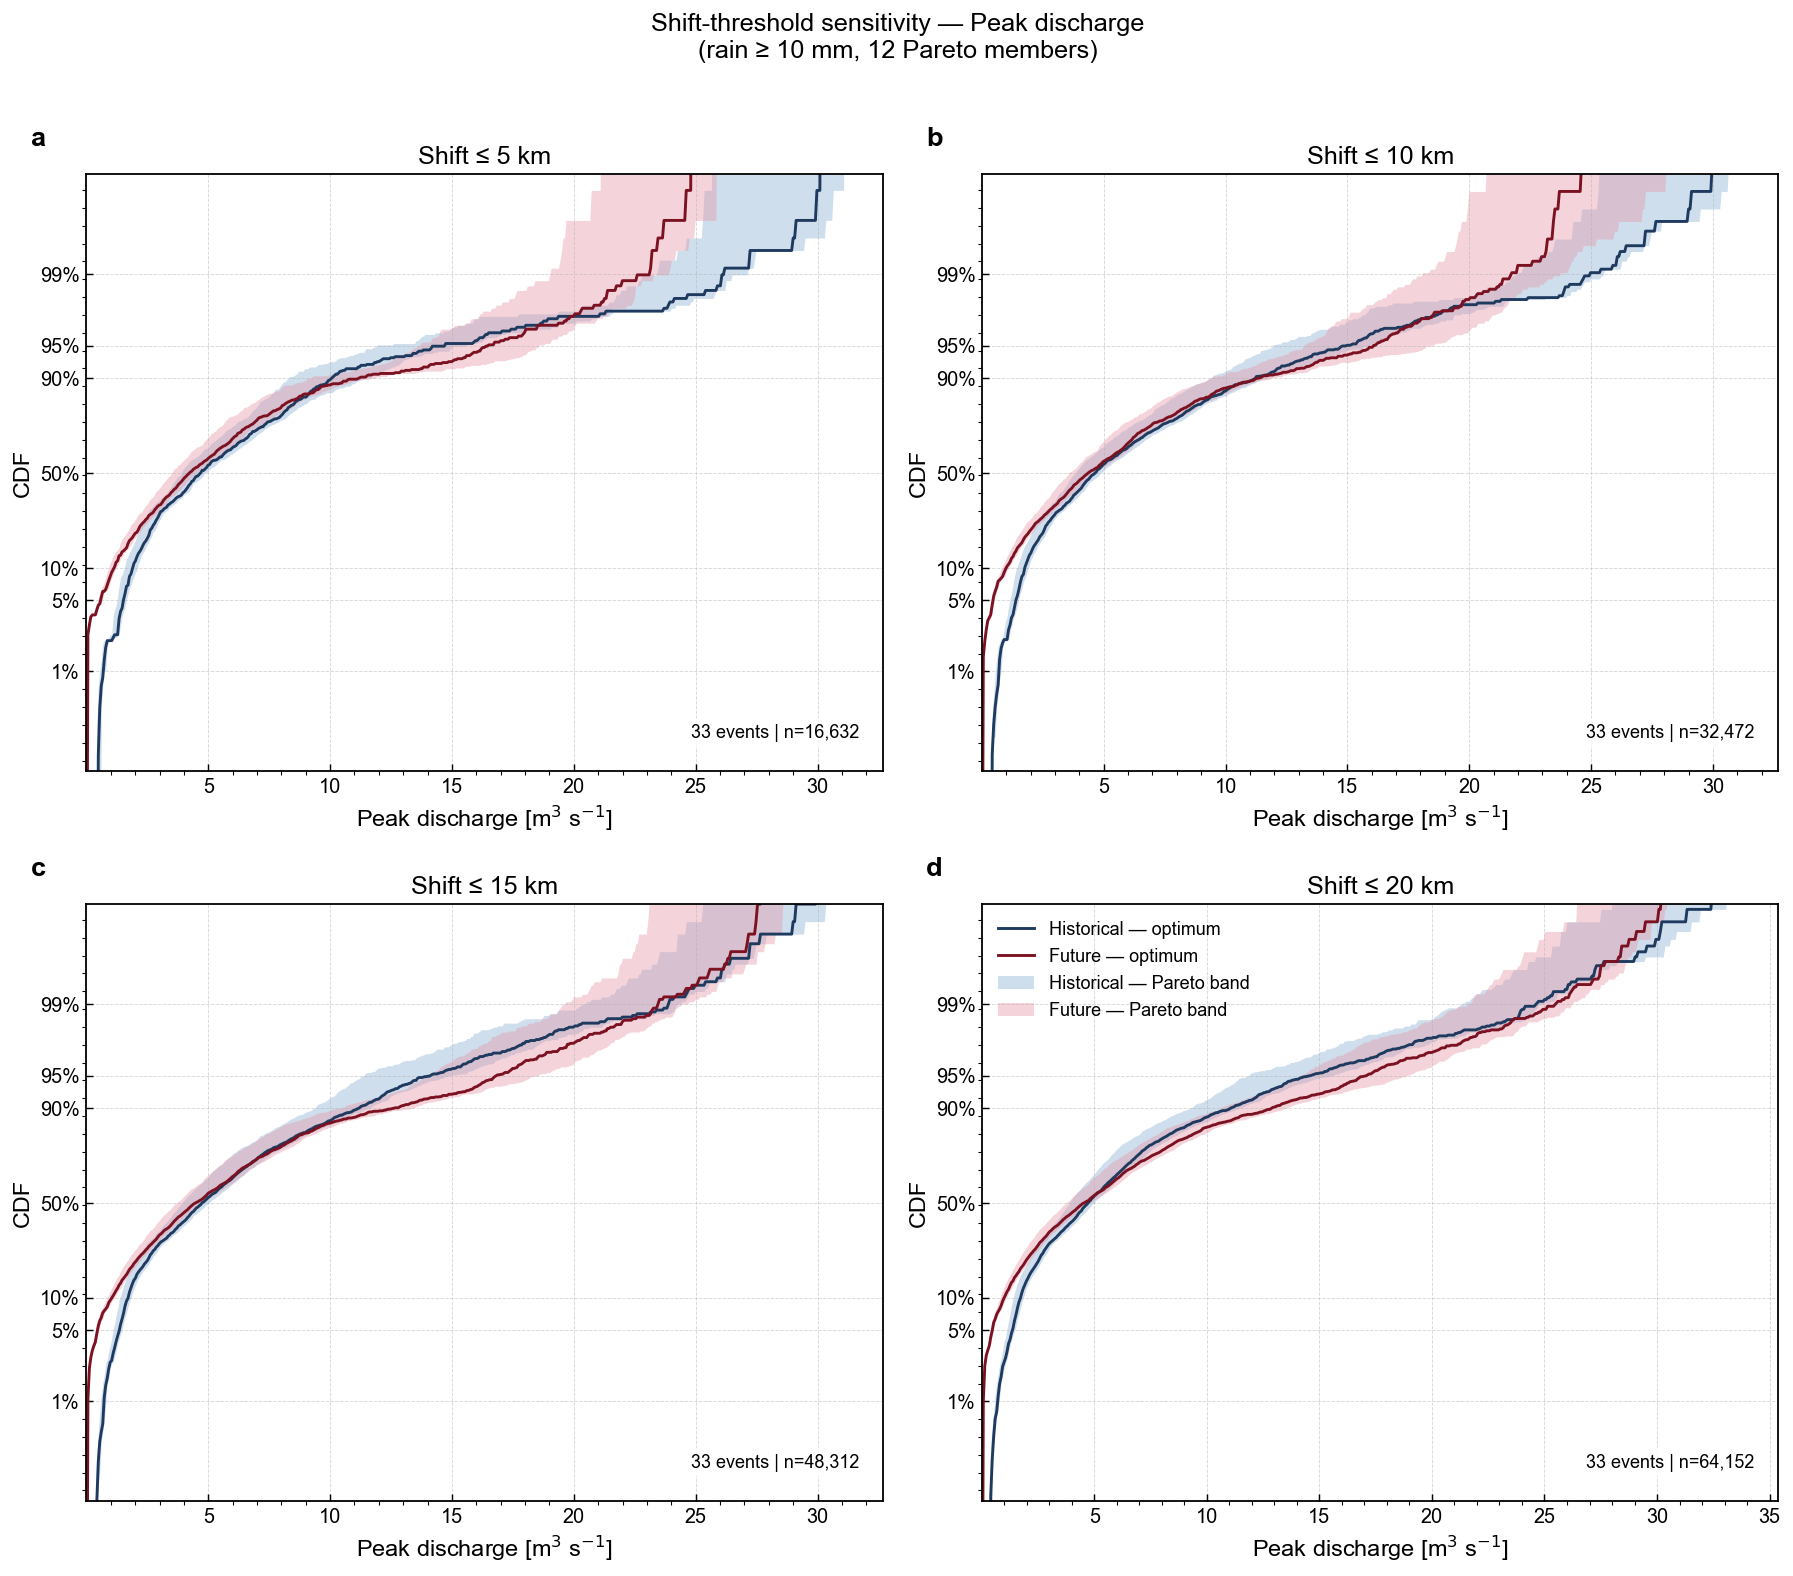

In [ ]:
# ── Section 3: Shift-threshold sensitivity — peak discharge ───────────────────
print("Computing shift-threshold sensitivity (peak discharge) ...")

ncols2 = 2
nrows2 = -(-len(SHIFT_THRESHOLDS_M) // ncols2)

fig, axes = plt.subplots(nrows2, ncols2, figsize=(7.0 * ncols2, 6.0 * nrows2), dpi=130)
axes_flat  = np.atleast_1d(axes).ravel()

for i, shift_m in enumerate(SHIFT_THRESHOLDS_M):
    (x, eh_lo, eh_hi, F_h_opt,
     ef_lo, ef_hi, F_f_opt,
     n_sims, n_ev) = _build_envelope_for_params(
         raw_dfs, _C_PH, _C_PF, rain_mm=DEFAULT_RAIN_MM, shift_m=shift_m
     )
    _draw_sensitivity_panel(
        axes_flat[i], x, F_h_opt, F_f_opt,
        eh_lo, eh_hi, ef_lo, ef_hi,
        x_label=r"Peak discharge [m$^3$ s$^{-1}$]",
        title=f"Shift \u2264 {shift_m // 1000} km",
        n_sims=n_sims, n_ev=n_ev,
        panel_label=panel_labels[i],
    )

handles = [
    mlines.Line2D([], [], color=_HIST_COLOR, lw=1.6, label="Historical — optimum"),
    mlines.Line2D([], [], color=_FUT_COLOR,  lw=1.6, label="Future — optimum"),
    Patch(facecolor=_HIST_FILL, alpha=0.4, edgecolor="none", label="Historical — Pareto band"),
    Patch(facecolor=_FUT_FILL,  alpha=0.4, edgecolor="none", label="Future — Pareto band"),
]
axes_flat[-1].legend(handles=handles, frameon=False, fontsize=10, loc="upper left")

fig.suptitle(
    f"Shift-threshold sensitivity — Peak discharge\n"
    f"(rain \u2265 {DEFAULT_RAIN_MM:.0f} mm, {len(available)} Pareto members)",
    fontsize=14, y=1.01,
)
fig.tight_layout()
out = FIG_DIR / "Fig_Sensitivity_ShiftThreshold_Peak.pdf"
fig.savefig(str(out), format="pdf", bbox_inches="tight", dpi=300)
print(f"Saved: {out}")
plt.show()


Computing shift-threshold sensitivity (total volume) ...
Saved: D:\MY_CODES\UrbanRunoffModeling_Refactored\outputs\climate\figures\Fig_Sensitivity_ShiftThreshold_Volume.pdf


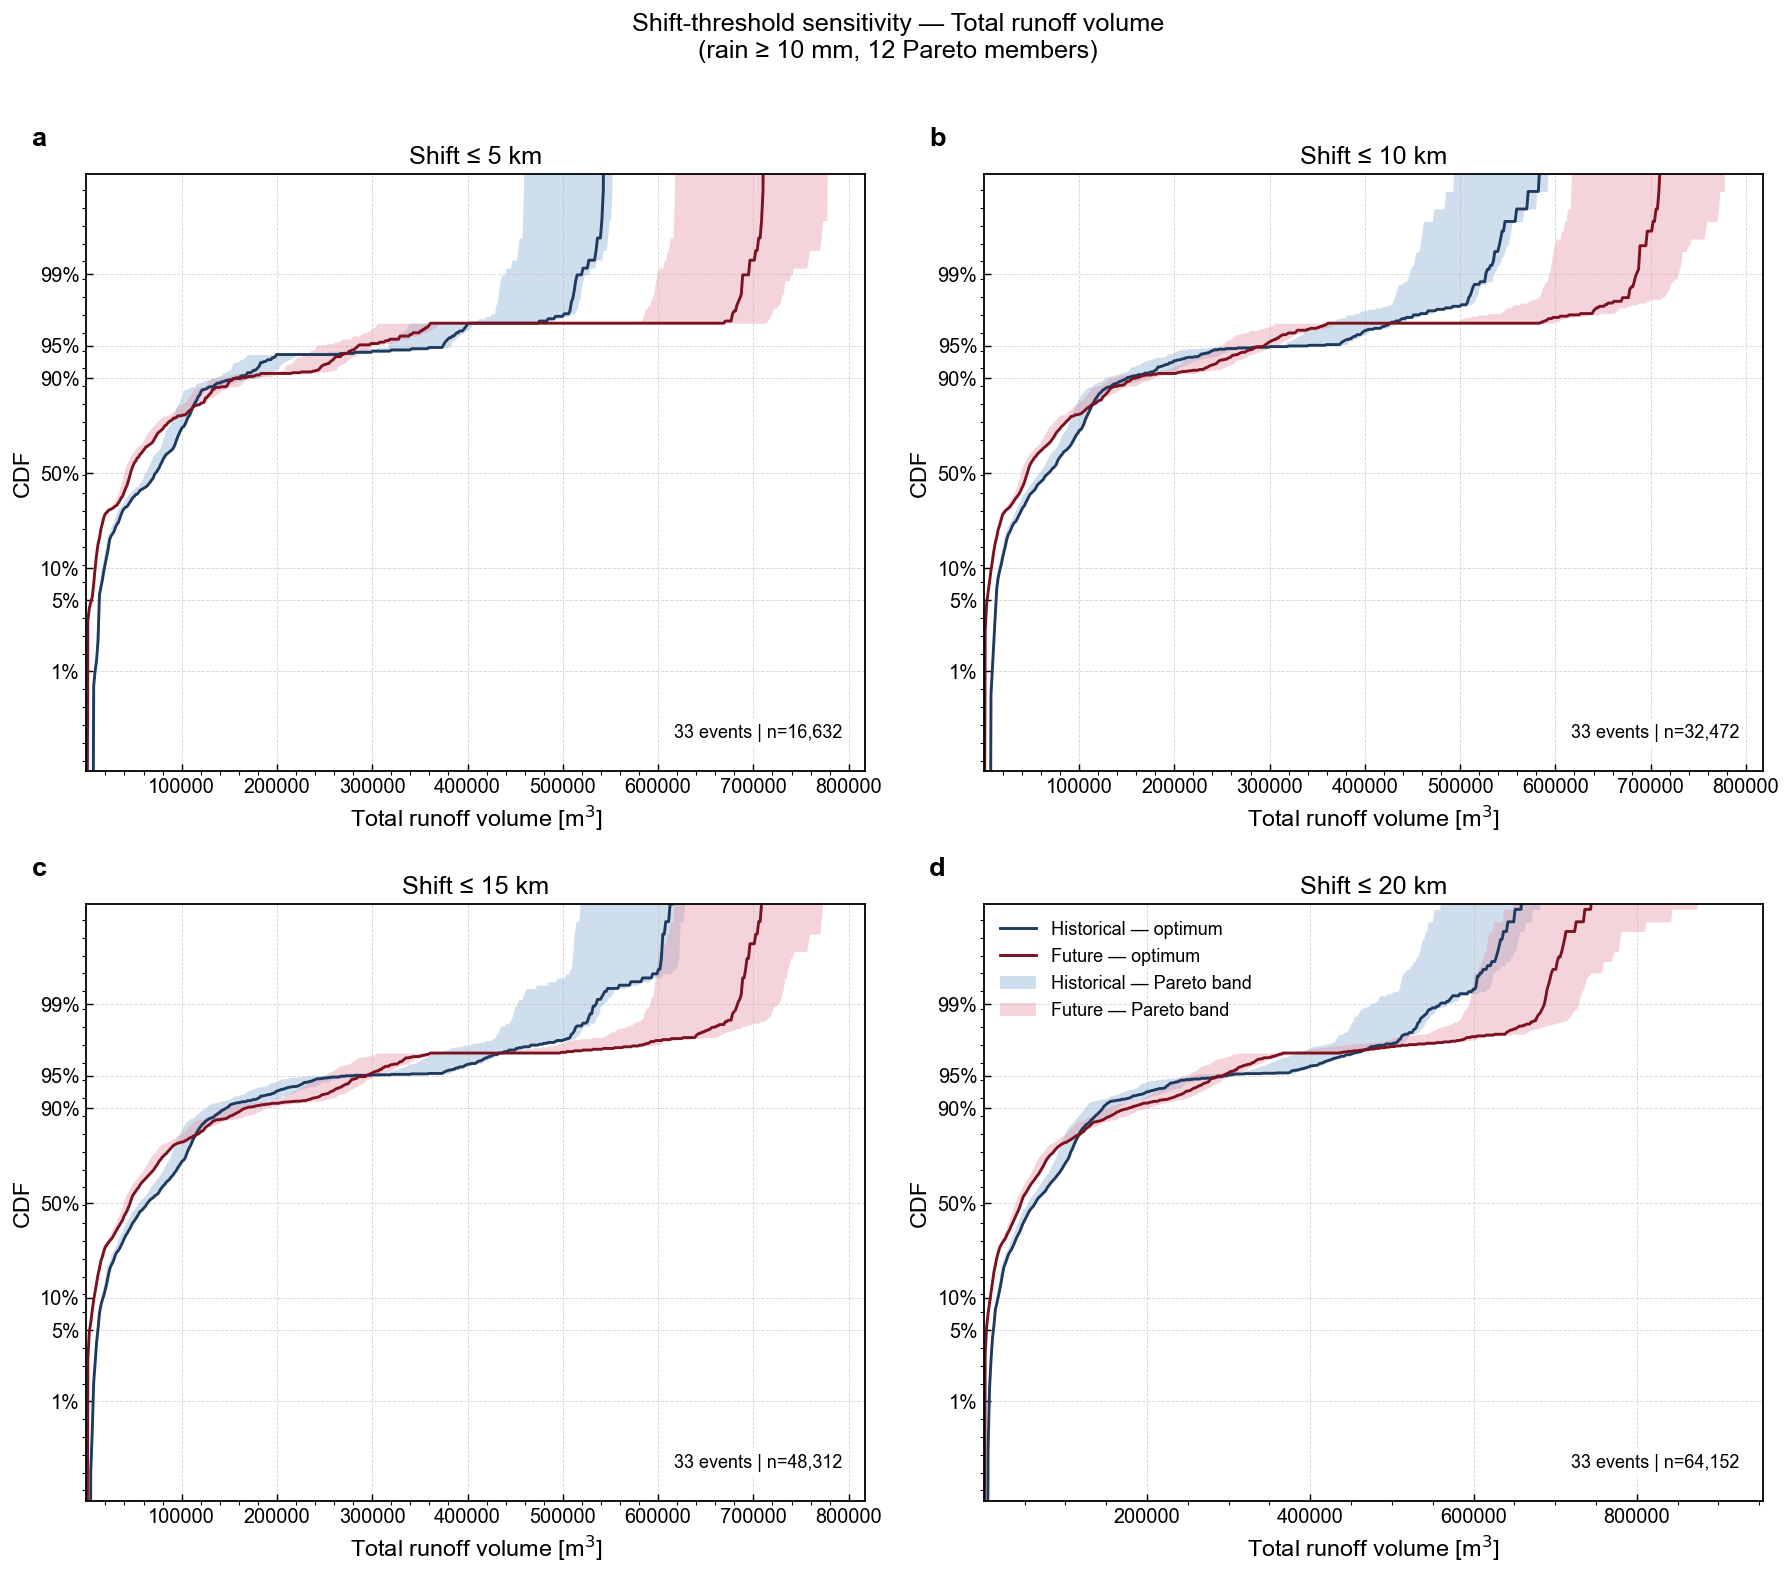

In [ ]:
# ── Section 4: Shift-threshold sensitivity — total volume ─────────────────────
print("Computing shift-threshold sensitivity (total volume) ...")

fig, axes = plt.subplots(nrows2, ncols2, figsize=(7.0 * ncols2, 6.0 * nrows2), dpi=130)
axes_flat  = np.atleast_1d(axes).ravel()

for i, shift_m in enumerate(SHIFT_THRESHOLDS_M):
    (x, eh_lo, eh_hi, F_h_opt,
     ef_lo, ef_hi, F_f_opt,
     n_sims, n_ev) = _build_envelope_for_params(
         raw_dfs, _C_VH, _C_VF, rain_mm=DEFAULT_RAIN_MM, shift_m=shift_m
     )
    _draw_sensitivity_panel(
        axes_flat[i], x, F_h_opt, F_f_opt,
        eh_lo, eh_hi, ef_lo, ef_hi,
        x_label=r"Total runoff volume [m$^3$]",
        title=f"Shift \u2264 {shift_m // 1000} km",
        n_sims=n_sims, n_ev=n_ev,
        panel_label=panel_labels[i],
    )

axes_flat[-1].legend(handles=handles, frameon=False, fontsize=10, loc="upper left")

fig.suptitle(
    f"Shift-threshold sensitivity — Total runoff volume\n"
    f"(rain \u2265 {DEFAULT_RAIN_MM:.0f} mm, {len(available)} Pareto members)",
    fontsize=14, y=1.01,
)
fig.tight_layout()
out = FIG_DIR / "Fig_Sensitivity_ShiftThreshold_Volume.pdf"
fig.savefig(str(out), format="pdf", bbox_inches="tight", dpi=300)
print(f"Saved: {out}")
plt.show()
